<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/MovieRatingPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
movies = pd.read_csv('/movie.csv')
ratings = pd.read_csv('/rating.csv')

df = pd.merge(ratings, movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2003488 entries, 0 to 2003487
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
 4   title      object 
 5   genres     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 91.7+ MB


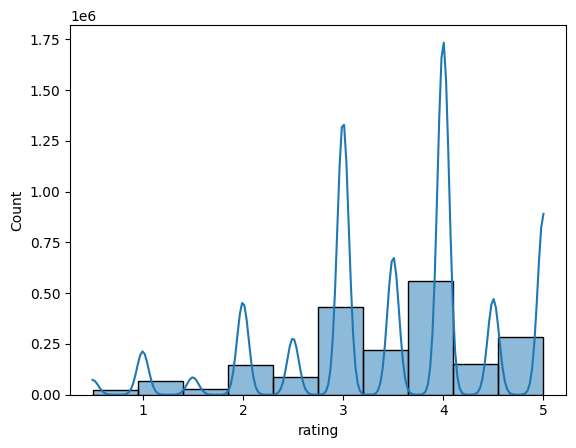

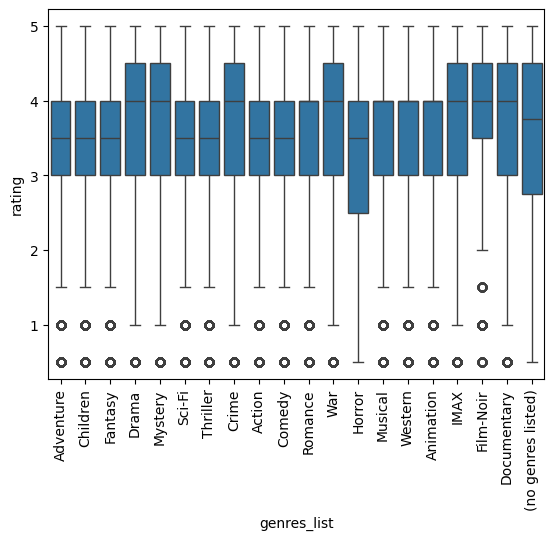

In [6]:
# Жалпы ақпарат
df.info()

# Null мәндерді тексеру
df.isnull().sum()

# Рейтингтерге статистика
df['rating'].describe()

# Рейтингтердің таралуы
sns.histplot(df['rating'], bins=10, kde=True)
plt.show()

# Фильм жанры бойынша орташа рейтинг
df['genres_list'] = df['genres'].str.split('|')  # жанрларды бөліп алу
df_exploded = df.explode('genres_list')
sns.boxplot(x='genres_list', y='rating', data=df_exploded)
plt.xticks(rotation=90)
plt.show()

In [11]:
# Genre encoding
genres_dummies = df['genres'].str.get_dummies(sep='|')
df = pd.concat([df, genres_dummies], axis=1)

# Drop unnecessary columns
df = df.drop(['title', 'genres', 'genres_list', 'timestamp'], axis=1)

# Fill NaN
df = df.fillna(0)

# Split
X = df.drop('rating', axis=1)
y = df['rating']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [21]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [22]:
# Кішірейту
df = df.sample(10000, random_state=42)

# Бағандарды тексеру
print("Columns:", df.columns)

# Target
y = df['rating']

# Feature (бар бағандарға ғана drop)
drop_cols = ['rating', 'title', 'genres', 'genres_list', 'timestamp']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=20, max_depth=10, n_jobs=-1, random_state=42)

rf.fit(X_train, y_train)

Columns: Index(['userId', 'movieId', 'rating', '(no genres listed)', 'Action',
       'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary',
       'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', '(no genres listed)',
       'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')


RandomForestRegressor(max_depth=10, n_estimators=20, n_jobs=-1, random_state=42)

In [23]:
models = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R²: {r2:.2f}")

Linear Regression -> RMSE: 0.99, R²: 0.04
Random Forest -> RMSE: 0.98, R²: 0.06
Gradient Boosting -> RMSE: 0.96, R²: 0.11


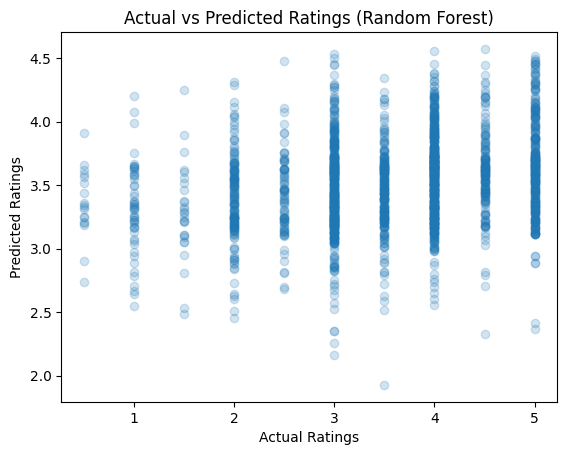

In [24]:
# Нақты vs болжау мәндерін салыстыру (Random Forest мысалы)
plt.scatter(y_test, rf.predict(X_test), alpha=0.2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings (Random Forest)')
plt.show()